# Lab 2: Data Quality Assessment & Preprocessing #

#### Khalid Waleed Alhilal
#### 2230000788
#### 8ma02

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

# Load dataset
df = pd.read_csv('data/laptops.csv')
df.head()

,Laptop,Status,Brand,Model,CPU,RAM,Storage,Storage type,GPU,Screen,Touch,Final Price
0,ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core...,New,Asus,ExpertBook,Intel Core i5,8,512,SSD,NaN,15.6,No,1009.00
1,Alurin Go Start Intel Celeron N4020/8GB/256GB ...,New,Alurin,Go,Intel Celeron,8,256,SSD,NaN,15.6,No,299.00
2,ASUS ExpertBook B1 B1502CBA-EJ0424X Intel Core...,New,Asus,ExpertBook,Intel Core i3,8,256,SSD,NaN,15.6,No,789.00
3,MSI Katana GF66 12UC-082XES Intel Core i7-1270...,New,MSI,Katana,Intel Core i7,16,1000,SSD,RTX 3050,15.6,No,1199.00
4,HP 15S-FQ5085NS Intel Core i5-1235U/16GB/512GB...,New,HP,15S,Intel Core i5,16,512,SSD,NaN,15.6,No,669.01


## Task 1: Identify Data Quality Assessment
check for missing values, duplicates, and inconsistent data types.

In [2]:
# Task 1: Data Quality Check
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicated Rows")
print(f"Total duplicates: {df.duplicated().sum()}")

print("\nData Types")
print(df.dtypes)

Missing Values
Laptop             0
Status             0
Brand              0
Model              0
CPU                0
RAM                0
Storage            0
Storage type      42
GPU             1371
Screen             4
Touch              0
Final Price        0
dtype: int64

Duplicated Rows
Total duplicates: 0

Data Types
Laptop           object
Status           object
Brand            object
Model            object
CPU              object
RAM               int64
Storage           int64
Storage type     object
GPU              object
Screen          float64
Touch            object
Final Price     float64
dtype: object


## Task 2: Apply Missing Value Strategy
Strategy: use the Median Imputation for numeric columns. 
The median is robust to outliers compared to the mean, making it a safer choice for hardware specs like Screen size or Price.

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    median_value = df[col].median()
    # Fill missing values with the median for numeric columns
    df[col] = df[col].fillna(median_value) 


categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

print("✅ Missing values handled successfully without warnings!")
# Verify that there are no more missing values
print(df.isnull().sum())

## Task 3: Detect and Handle Outliers 
We will focus on the `Final Price` column to detect extremely expensive laptops and cap them using the Interquartile Range (IQR).

Number of Outliers in Final Price: 0


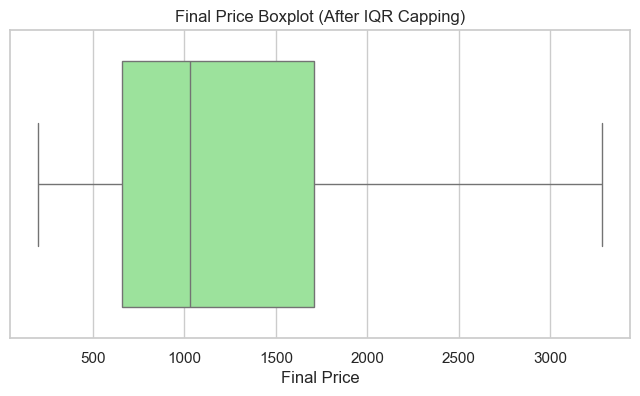

In [9]:
Q1 = df['Final Price'].quantile(0.25)
Q3 = df['Final Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Final Price'] < lower_bound) | (df['Final Price'] > upper_bound)]
print(f"Number of Outliers in Final Price: {len(outliers)}")

# Capping the outliers to the upper and lower bounds
df['Final Price'] = np.where(df['Final Price'] > upper_bound, upper_bound, df['Final Price'])
df['Final Price'] = np.where(df['Final Price'] < lower_bound, lower_bound, df['Final Price'])

# Boxplot after handling outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Final Price'], color='lightgreen')
plt.title("Final Price Boxplot (After IQR Capping)")
plt.show()

## Task 4: Normalize Numerical Features
- Min-Max Scaling: Applied to `Storage` to scale values between 0 and 1.
- Z-score Standardization: Applied to `RAM` to center the data (mean=0, std=1).

In [10]:
min_max_scaler = MinMaxScaler()
z_score_scaler = StandardScaler()

# Min-Max Scaling on 'Storage'
df['Storage_MinMax'] = min_max_scaler.fit_transform(df[['Storage']])

# Z-score Standardization on 'RAM'
df['RAM_Zscore'] = z_score_scaler.fit_transform(df[['RAM']])

df[['Storage', 'Storage_MinMax', 'RAM', 'RAM_Zscore']].head()

,Storage,Storage_MinMax,RAM,RAM_Zscore
0,512,0.128,8,-0.751494
1,256,0.064,8,-0.751494
2,256,0.064,8,-0.751494
3,1000,0.250,16,0.059410
4,512,0.128,16,0.059410


## Task 5: Apply PCA & Interpret Explained Variance
We will apply Principal Component Analysis (PCA) to reduce the dimensionality of our numeric features.

Explained Variance by PC1: 66.09%
Explained Variance by PC2: 20.11%
Total Information Retained: 86.19%


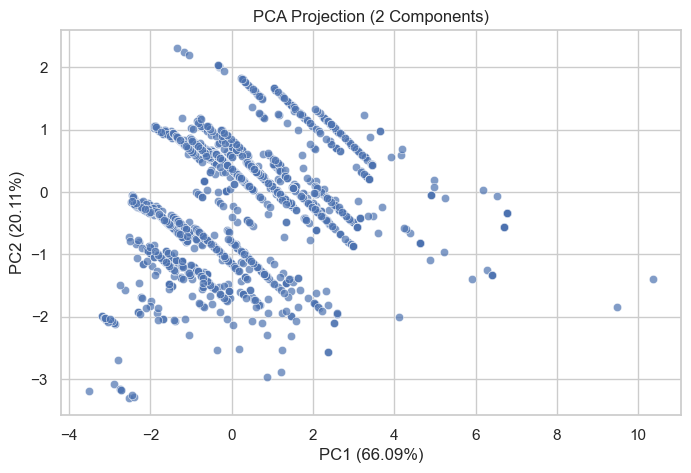

In [11]:
# Select numeric features for PCA
pca_features = ['RAM', 'Storage', 'Screen', 'Final Price']
X_scaled = StandardScaler().fit_transform(df[pca_features])

# Apply PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance by PC1: {explained_variance[0]*100:.2f}%")
print(f"Explained Variance by PC2: {explained_variance[1]*100:.2f}%")
print(f"Total Information Retained: {sum(explained_variance)*100:.2f}%")

# Plot PCA
plt.figure(figsize=(8,5))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, alpha=0.7)
plt.title("PCA Projection (2 Components)")
plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}%)")
plt.show()